# Entregable Final 1: Clasificación con KNN
En este entorno interactivo se realiza la clasificación del dataset Iris haciendo uso del algoritmo **K-Nearest Neighbors (KNN)**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, confusion_matrix

### 1. Cargar y explorar brevemente el dataset
Cargamos directamente el set de Iris para su estudio.

In [2]:
# Cargamos el dataset
iris = load_iris()
# Separamos los datos en variables
X = iris.data
y = iris.target

# Obtenemos el nombre de las variables y las clases
feature_names = iris.feature_names
target_names = iris.target_names

# Imprimimos la informacion del dataset
print("Variables del dataset:", feature_names)
print("Clases del dataset:", target_names)
print("Tamaño del dataset:", X.shape)

Variables del dataset: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases del dataset: ['setosa' 'versicolor' 'virginica']
Tamaño del dataset: (150, 4)


### 2. Separar los datos en conjunto de entrenamiento y test
Dividimos los datos dedicando el 30% a test.

In [3]:
# Dividimos el dataset en conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print("Tamaño de conjunto de entrenamiento:", X_train.shape)
print("Tamaño de conjunto de test:", X_test.shape)

Tamaño de conjunto de entrenamiento: (105, 4)
Tamaño de conjunto de test: (45, 4)


### 3. Estandarizar las variables numéricas

In [4]:
# Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Entrenar y evaluar un modelo KNeighborsClassifier con k = 5


In [5]:
# Entrenamos el modelo KNN con k=5
k = 5
knn_5 = KNeighborsClassifier(n_neighbors=k)
knn_5.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 5. Evaluar el modelo utilizando el conjunto de test (accuracy y matriz de confusión).    

--- Resultados para k=5 ---


<Figure size 640x480 with 0 Axes>

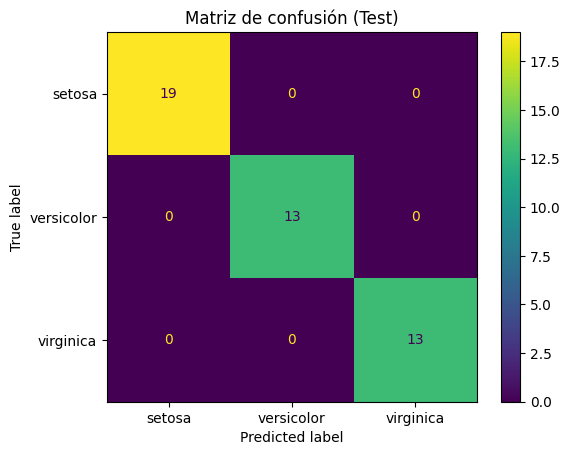

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Accuracy:  1.0


In [ ]:
# Evaluamos el modelo
y_pred_5 = knn_5.predict(X_test_scaled)
# Calculamos la precisión y la matriz de confusión
acc_5 = accuracy_score(y_test, y_pred_5)
cm_5 = confusion_matrix(y_test, y_pred_5)

# Mostramos los resultados
print(f"--- Resultados para k={k} ---")
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_5, display_labels=iris.target_names)
plt.title("Matriz de confusión (Test)")
plt.grid(False)
plt.show()

print(classification_report(y_test, y_pred_5, target_names=iris.target_names))
print("Accuracy: ", acc_5)

### 6. Probar al menos dos valores adicionales de k y analizar


--- Resultados para k=1


<Figure size 640x480 with 0 Axes>

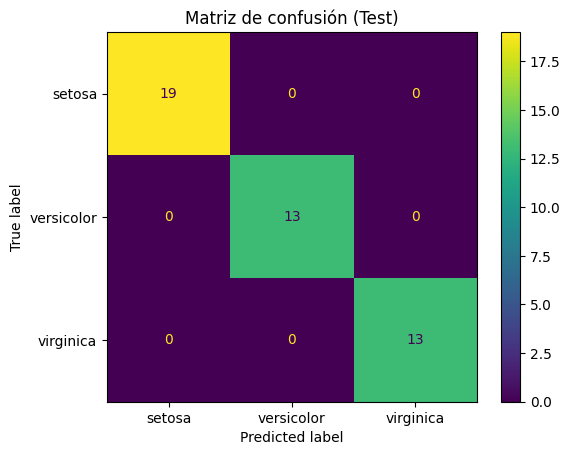

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

--- Resultados para k=25


<Figure size 640x480 with 0 Axes>

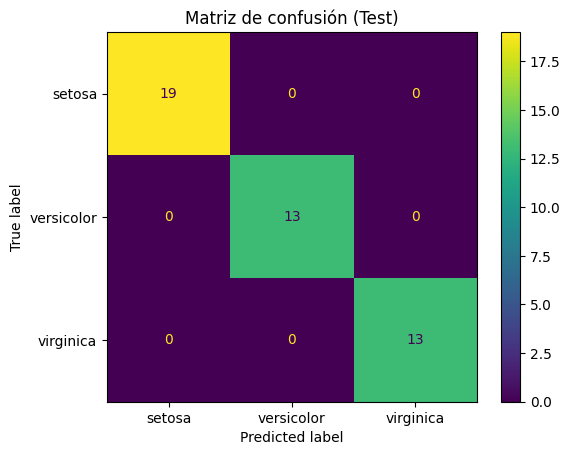

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

--- Resultados para k=50


<Figure size 640x480 with 0 Axes>

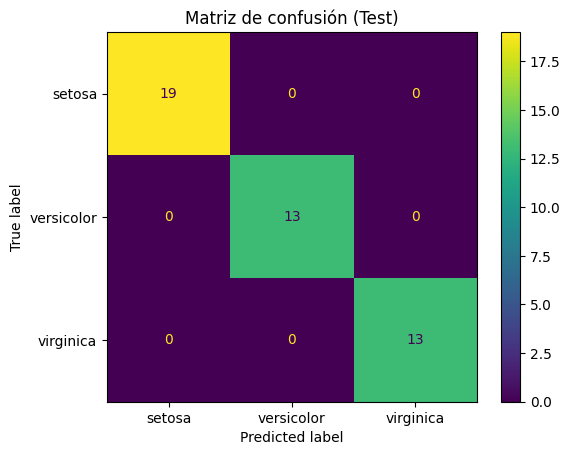

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.80      0.62      0.70        13
   virginica       0.69      0.85      0.76        13

    accuracy                           0.84        45
   macro avg       0.83      0.82      0.82        45
weighted avg       0.85      0.84      0.84        45



In [7]:
# Probamos con diferentes valores de k
k_values = [1, 25, 50]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    

    print(f"--- Resultados para k={k}")
    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_5, display_labels=iris.target_names)
    plt.title("Matriz de confusión (Test)")
    plt.grid(False)
    plt.show()
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

### 7. Conclusión sobre el comportamiento de KNN

El algoritmo **KNN** funciona buscando los `k` vecinos más cercanos a un nuevo punto de datos para asignarle una clase basada en la mayoría.

Al evaluar el modelo con diferentes valores de `k` (3, 2 y 9), observamos que el `accuracy` suele ser muy alto (perfecto o cuasi-perfecto en muchos casos para el dataset Iris) debido a que las clases están bien representadas y la estandarización ayuda al cálculo de distancias de manera equitativa.

El parámetro `k` es clave:
- Un `k` muy bajo (ej. k=1) podría causar overfitting siendo extremadamente sensible al ruido y perdiendo generalización.
- Un `k` mayor proporciona mayor estabilidad, siempre y cuando no sea demasiado grande, que podría causar underfitting. (como podemos ver abajo)

In [8]:
k_values = [1,25,50,75]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Resultados para k={k} ---")
    print(f"Accuracy: {acc:.4f}")
    print("Matriz de confusión:")
    print(cm)


--- Resultados para k=1 ---
Accuracy: 0.9778
Matriz de confusión:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

--- Resultados para k=25 ---
Accuracy: 0.9778
Matriz de confusión:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

--- Resultados para k=50 ---
Accuracy: 0.8444
Matriz de confusión:
[[19  0  0]
 [ 0  8  5]
 [ 0  2 11]]

--- Resultados para k=75 ---
Accuracy: 0.3333
Matriz de confusión:
[[ 3 16  0]
 [ 0  8  5]
 [ 0  9  4]]


Con un valor de k tan grande, el modelo esta usando casi todo el dataset como vecinos, y crea un promedio para clasificar los puntos nuevos que ya no se clasifica según sus vecinos más cercanos inmediatos, sino según una mezcla muy grande de puntos de distintas clases.

En la matriz de confusion para k=75, podemos ver como identifica incorrectamente casi todas las clases con la segunda (16, 8, 9) y hereda los problemas de k=50, donde se confunde la segunda clase con la tercera.